In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from matplotlib.patches import Ellipse
%config InlineBackend.figure_format = 'retina'

In [30]:
ndata = np.load("Obs_Dr_stacking.npy")

In [31]:
ndata_Uni = np.load("stacking data.npy")

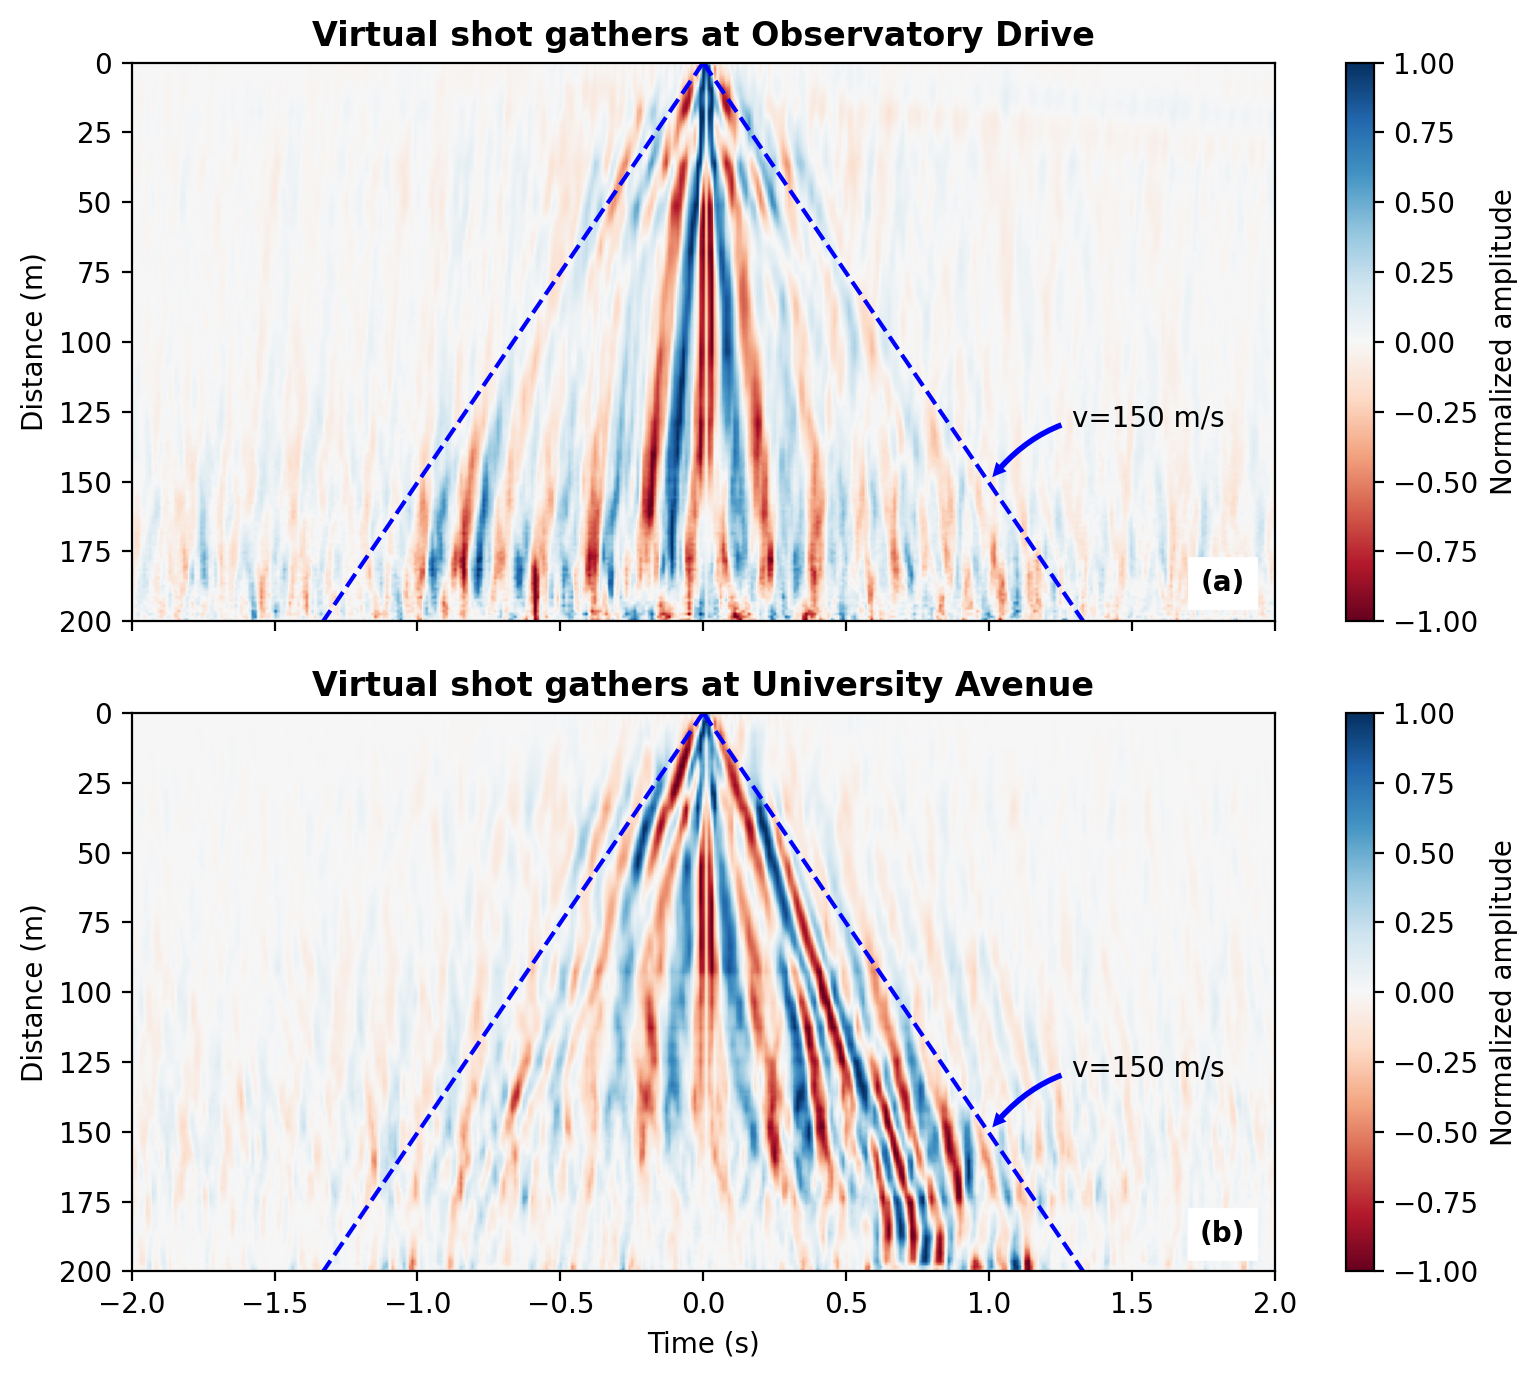

In [10]:
fig, axs = plt.subplots(2,1,figsize = (8,7),sharex = True)
im1 = axs[0].imshow(
    ndata,
    cmap="RdBu",
    extent=[-3, 3, 0, 200],
    aspect="auto",
    origin="lower",
)
# axs[0].plot([0,1],[0,200],ls = '--',c = 'b')
# axs[0].plot([0,-1],[0,200],ls = '--',c = 'b')

axs[0].plot([0,1.33],[0,200],ls = '--',c = 'b')
axs[0].plot([0,-1.33],[0,200],ls = '--',c = 'b')

cbar = fig.colorbar(im1,ax = axs[0])
cbar.set_label("Normalized amplitude")

# axs[0].set_xlabel("time (s)")
axs[0].set_ylabel("Distance (m)")
el = Ellipse((2, -1), 0.5, 0.5)
# axs[0].annotate('v=200 m/s',
#             xy=(0.52, 100), xycoords='data',
#             xytext=(30,20), textcoords='offset points',
#             arrowprops=dict(arrowstyle="simple",
#                             fc="b", ec="none",
#                             patchB=el,
#                             connectionstyle="arc3,rad=0.3"))
axs[0].annotate('v=150 m/s',
            xy=(1.0, 150), xycoords='data',
            xytext=(30,20), textcoords='offset points',
            arrowprops=dict(arrowstyle="simple",
                            fc="b", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.3"))
axs[0].invert_yaxis()
axs[0].set_xlim(-2,2)
axs[0].set_title('Virtual shot gathers at Observatory Drive',fontweight = 'bold')

im2 = axs[1].imshow(
    ndata_Uni,
    cmap="RdBu",
    extent=[-3, 3, 0, 200],
    aspect="auto",
    origin="lower",
)
cbar1 = fig.colorbar(im2,ax = axs[1])
cbar1.set_label("Normalized amplitude")

# axs[1].plot([0,1],[0,200],ls = '--',c = 'b')
# axs[1].plot([0,-1],[0,200],ls = '--',c = 'b')

axs[1].plot([0,1.33],[0,200],ls = '--',c = 'b')
axs[1].plot([0,-1.33],[0,200],ls = '--',c = 'b')

axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Distance (m)")

axs[1].invert_yaxis()
axs[1].set_xlim(-2,2)

el = Ellipse((2, -1), 0.5, 0.5)
# axs[1].annotate('v=200 m/s',
#             xy=(0.52, 100), xycoords='data',
#             xytext=(30,20), textcoords='offset points',
#             arrowprops=dict(arrowstyle="simple",
#                             fc="b", ec="none",
#                             patchB=el,
#                             connectionstyle="arc3,rad=0.3"))
axs[1].annotate('v=150 m/s',
            xy=(1.0, 150), xycoords='data',
            xytext=(30,20), textcoords='offset points',
            arrowprops=dict(arrowstyle="simple",
                            fc="b", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.3"))

axs[1].set_title('Virtual shot gathers at University Avenue',fontweight = 'bold')
fig.text(0.77, 0.575, '(a)', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white',edgecolor = 'w'))
fig.text(0.77, 0.11, '(b)', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white',edgecolor = 'w'))

plt.tight_layout()
fig.savefig('virtual_shot_gathers_updated.png', dpi=600,bbox_inches = 'tight')

plt.show()

### Henry Mall

In [32]:
from obspy import Trace, Stream, UTCDateTime
from obspy.core.inventory import Inventory, Network, Station, Channel, Site
from obspy.core.utcdatetime import UTCDateTime
from datetime import datetime, timedelta
import pyasdf
import obspy
from scipy.signal import savgol_filter
import matplotlib.dates as mdates
from datetime import datetime, timezone
from obspy.signal.detrend import polynomial
from obspy.signal.filter import bandpass

In [33]:
das_data = np.load("1230ch.npy")

In [34]:
das_data.shape

(101, 48000)

In [35]:
sampling_rate = 100.0  # sampling rate (Hz)
start_time = UTCDateTime(2019, 11, 6, 21, 49,49)  # start time

In [36]:
stream = Stream()

In [37]:
inventory = Inventory(networks=[], source="Generated by ObsPy")

In [38]:
for i in range(101):
    
    stats = {
        'network': "CI",  # 
        'station': f"LOC{i+1230}",  # 
        'location': '',  # 
        'channel': 'BHZ',  # 
        'npts': das_data.shape[1],  
        'sampling_rate': sampling_rate,  
        'starttime': start_time  
    }

    trace = Trace(data=das_data[i, :], header=stats)
    stream.append(trace)  #

    network_code = "CI"
    station_code = f"LOC{i+1230}"
    channel_code = "BHZ"
    latitude = i/110.57427281141281 # 
    longitude = 0  # 
    elevation = 0  # 
    depth = 0.0  # 
    azimuth = 0.0  # 
    dip = -90.0  # 
    
    network = Network(code=network_code, description="My Seismic Network")

    station = Station(
        code=station_code,
        latitude=latitude,
        longitude=longitude,
        elevation=elevation,
        site=Site(name=station_code),  
        creation_date=UTCDateTime(2020, 1, 1)  
    )

    channel = Channel(
    code=channel_code,
    location_code="",  
    latitude=0.0,  
    longitude=0.0, 
    elevation=0.0, 
    depth=0.0,  
    azimuth=0.0,  
    dip=-90.0,  
    sample_rate=sampling_rate  
    )

    station.channels.append(channel)

    network.stations.append(station)

    inventory.networks.append(network)

inventory.write("output_station_1101.xml", format="STATIONXML")

In [40]:
stream_copy = stream.copy()

In [42]:
stream_copy.filter("bandpass", freqmin=freq_min, freqmax = freq_max, corners=corners, zerophase=zerophase)

101 Trace(s) in Stream:

CI.LOC1230..BHZ | 2019-11-06T21:49:49.000000Z - 2019-11-06T21:57:48.990000Z | 100.0 Hz, 48000 samples
...
(99 other traces)
...
CI.LOC1330..BHZ | 2019-11-06T21:49:49.000000Z - 2019-11-06T21:57:48.990000Z | 100.0 Hz, 48000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

In [44]:
for tr in stream_copy:
    tr.data = tr.data/max(abs(tr.data))
    tr.data = tr.data-np.mean(tr.data)
    # tr.data = savgol_filter(tr.data, window_length=21, polyorder=2)


In [45]:
duration = 8 * 60
npts = int(100 * duration)
times = np.linspace(0, duration, npts)

In [46]:
timestamps = [start_time.datetime + timedelta(seconds=t) for t in times]

In [49]:
hm_array = np.zeros((das_data.shape))
for i in range(101):
    hm_array[i] = stream_copy[i].data/max(abs(stream_copy[i].data))

In [50]:
ndata_hm = np.load("Henry_Mall_stacking.npy")

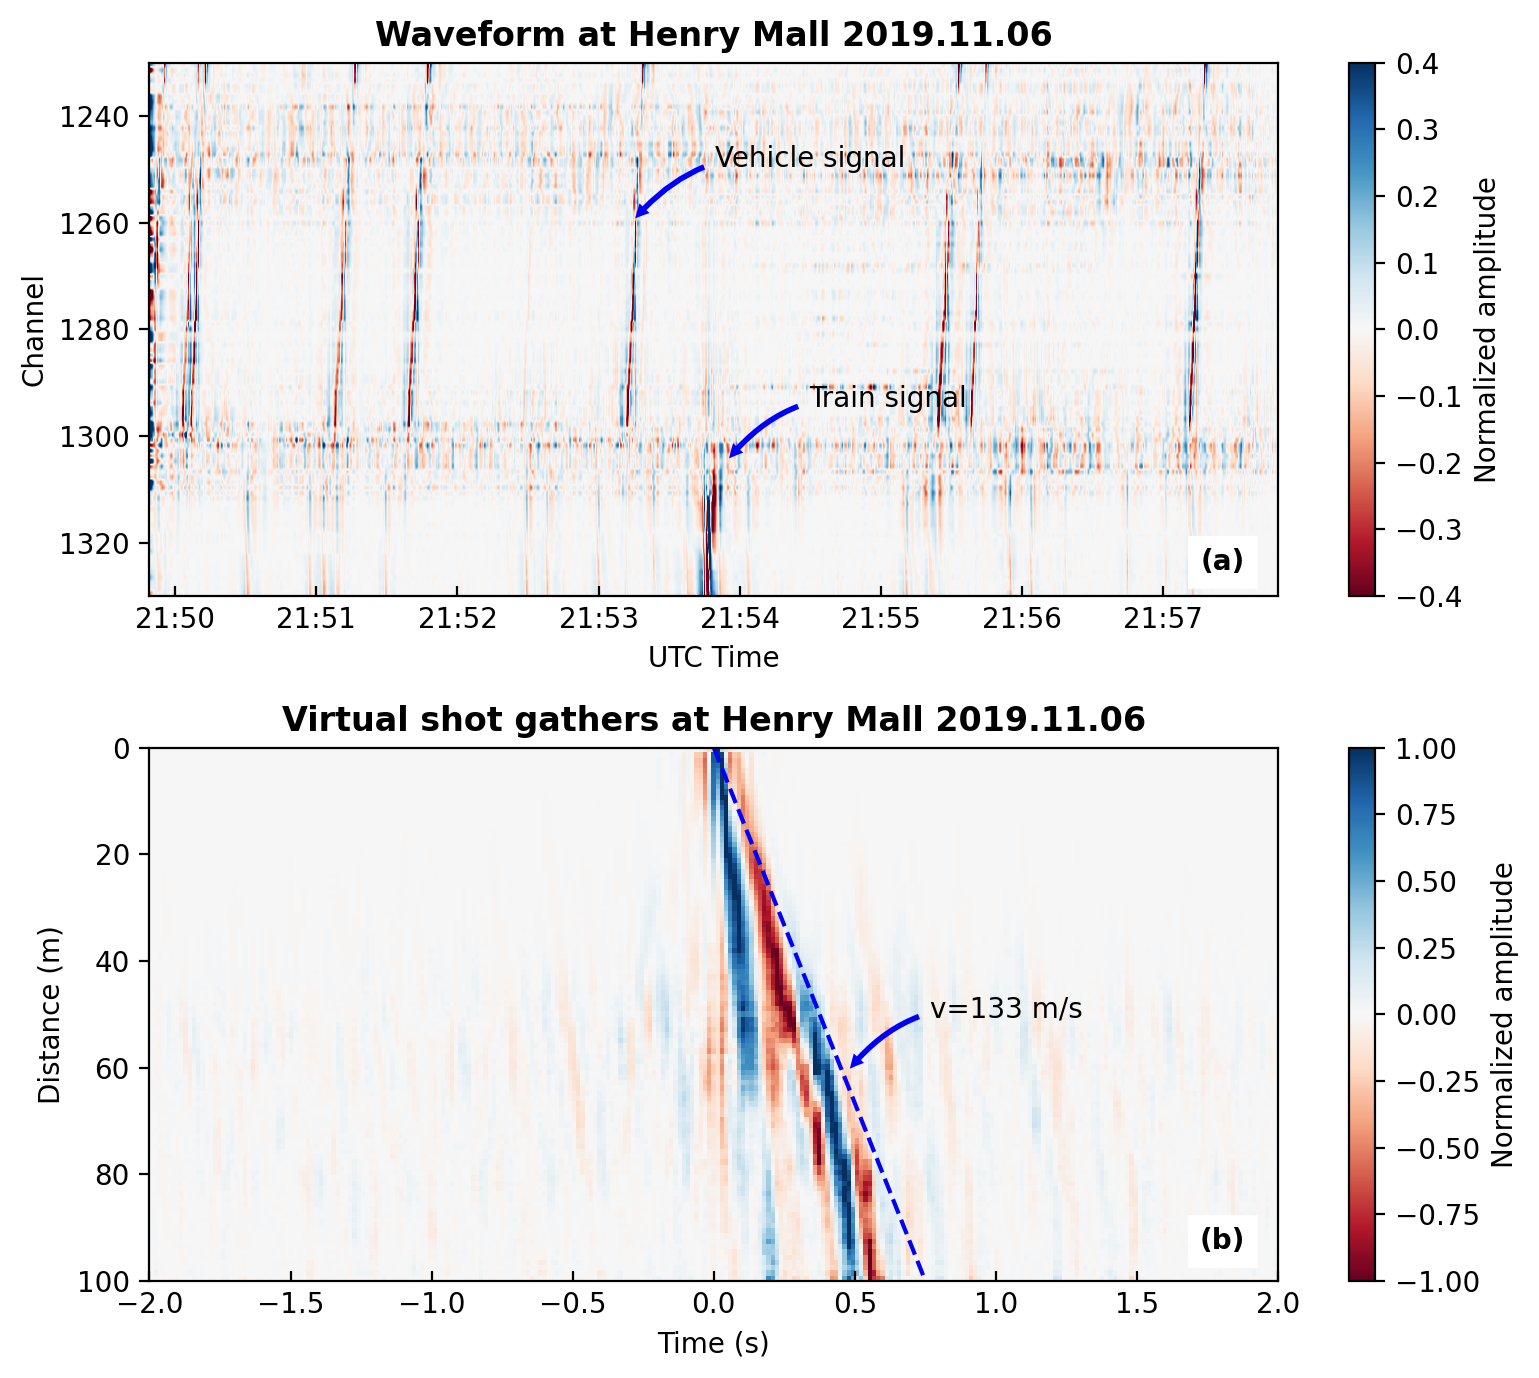

In [58]:
fig, axs = plt.subplots(2,1,figsize = (8,7))
im1 = axs[0].imshow(hm_array, aspect='auto',extent=[timestamps[0], timestamps[-1], 1230, 1330],
                    origin='lower',
                    cmap = 'RdBu',
                    vmin=-0.4, vmax=0.4)
axs[0].set_xlabel('UTC Time')
axs[0].set_ylabel('Channel')
# axs[0].set_ylim(1250,1300)

cbar = fig.colorbar(im1,ax = axs[0])
cbar.set_label("Normalized amplitude")

# axs[0].set_yticks(np.linspace(1250, 1300, 6))
# axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axs[0].tick_params(axis='x', which='both', direction='in')  

axs[0].invert_yaxis()
# axs[0].set_xlim(datetime(2019, 11, 6, 21, 52, 00), datetime(2019, 11, 6, 21, 57, 00))

el = Ellipse((2, -1), 0.5, 0.5)
axs[0].annotate('Vehicle signal',
            xy=(timestamps[20500], 1260), xycoords='data',
            xytext=(30,20), textcoords='offset points',
            arrowprops=dict(arrowstyle="simple",
                            fc="b", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.3"))
axs[0].annotate('Train signal',
            xy=(timestamps[24500], 1305), xycoords='data',
            xytext=(30,20), textcoords='offset points',
            arrowprops=dict(arrowstyle="simple",
                            fc="b", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.3"))
# axs[0].text(timestamps[700],1297,'(a)',fontweight = 'bold',
#            bbox=dict(facecolor='white',edgecolor = 'w'))
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

axs[0].set_title('Waveform at Henry Mall 2019.11.06',fontweight = 'bold')

###############################################################################

im2 = axs[1].imshow(
    ndata_hm,
    cmap="RdBu",
    extent=[-3, 3, 0, 100],
    aspect="auto",
    origin="lower"
)

axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Distance (m)")

axs[1].set_xlim(-2,2)
axs[1].invert_yaxis()
axs[1].set_title('Virtual shot gathers at Henry Mall 2019.11.06',fontweight = 'bold')
axs[1].tick_params(axis='x', which='both', direction='in')  
# axs[1].plot([0,0.5],[0,100],ls = '--',c = '#2ca02c')
axs[1].plot([0,0.75],[0,100],ls = '--',c = 'b')

cbar1 = fig.colorbar(im2,ax = axs[1])
cbar1.set_label("Normalized amplitude")
el = Ellipse((2, -1), 0.5, 0.5)
# axs[1].annotate('v=200 m/s',
#             xy=(0.2, 45), xycoords='data',
#             xytext=(30,20), textcoords='offset points',
#             arrowprops=dict(arrowstyle="simple",
#                             fc="0.6", ec="none",
#                             patchB=el,
#                             connectionstyle="arc3,rad=0.3"))
axs[1].annotate('v=133 m/s',
            xy=(0.47, 61), xycoords='data',
            xytext=(30,20), textcoords='offset points',
            arrowprops=dict(arrowstyle="simple",
                            fc="b", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.3"))
# axs[1].text(-1.94,94,'(b)',fontweight = 'bold',
#             bbox=dict(facecolor='white',edgecolor = 'w'))

fig.text(0.77, 0.59, '(a)', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white',edgecolor = 'w'))
fig.text(0.77, 0.105, '(b)', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white',edgecolor = 'w'))

plt.tight_layout()
fig.savefig('hm_vitual_shot_gathers_updated_1230.png', dpi=600,bbox_inches = 'tight')

plt.show()